C:\Users\yogst\AppData\Local\Temp\ipykernel_46392\2446168821.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


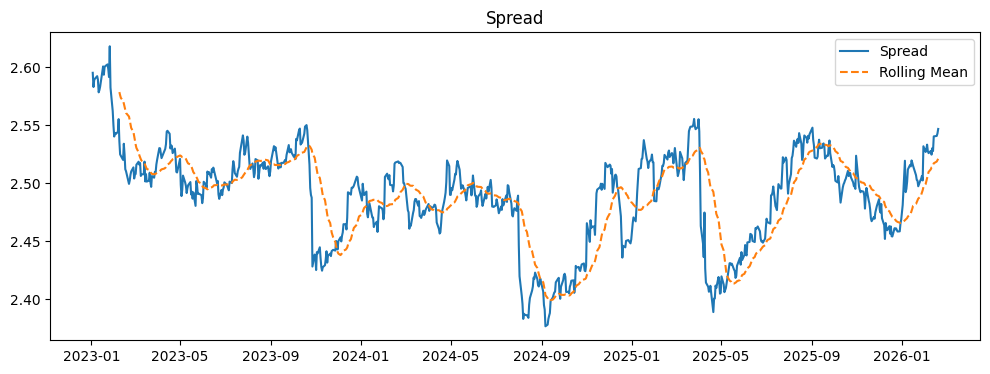

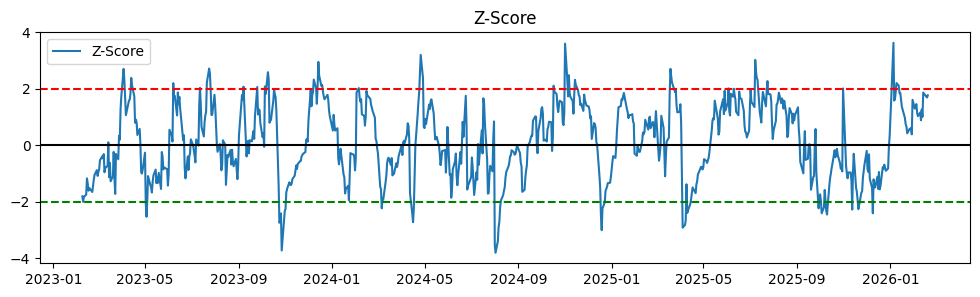

In [5]:
# Computer and Visualise the Z-Score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant

price_data = pd.read_csv("../data/prices.csv", index_col = 0, parse_dates = True).dropna()

# Pick the pair
x = np.log(price_data['XOM'])
y = np.log(price_data['CVX'])

# Compute hedge ratio (beta)
X = add_constant(x)
model = OLS(y, X).fit()
beta = model.params[1]

# Spread
spread = y - beta * x

# Rolling stats
window = 26  # approx half-life
spread_mean = spread.rolling(window=window).mean()
spread_std = spread.rolling(window=window).std()

# Z-score
zscore = (spread - spread_mean) / spread_std

# Visualize
plt.figure(figsize=(12,4))
plt.plot(spread, label='Spread')
plt.title("Spread")
plt.plot(spread_mean, label='Rolling Mean', linestyle='--')
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(zscore, label='Z-Score')
plt.title("Z-Score")
plt.axhline(0, color='black')
plt.axhline(2, color='red', linestyle='--')
plt.axhline(-2, color='green', linestyle='--')
plt.legend()
plt.show()

In [6]:
# Simulate positions

position = pd.Series(0, index=spread.index)

# Enter positions
position[zscore > 2] = -1  # short
position[zscore < -2] = 1  # long

# Exit positions at mean
position[(zscore.shift(1) > 0) & (zscore <= 0)] = 0
position[(zscore.shift(1) < 0) & (zscore >= 0)] = 0

# Forward fill positions
position = position.ffill().fillna(0)

# Compute daily returns of spread
spread_ret = spread.diff()
strategy_ret = position.shift(1) * spread_ret

In [8]:
# Daily stats
daily_mean = strategy_ret.mean()
daily_std = strategy_ret.std()

# Sharpe (annualized)
sharpe = daily_mean / daily_std * np.sqrt(252)

# CAGR : Compound Annual Growth Rate, measures an investments annual growth over time
cum_ret = (strategy_ret + 1).cumprod()
cagr = (cum_ret[-1])**(252/len(strategy_ret)) - 1

# Max Drawdown
roll_max = cum_ret.cummax()
drawdown = (cum_ret - roll_max) / roll_max
max_dd = drawdown.min()

print("Sharpe:", sharpe)
print("CAGR:", cagr)
print("Max Drawdown:", max_dd)

Sharpe: 0.1264007954703967
CAGR: 0.005769405834470165
Max Drawdown: -0.09763028563164598


C:\Users\yogst\AppData\Local\Temp\ipykernel_46392\3111292948.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cagr = (cum_ret[-1])**(252/len(strategy_ret)) - 1


### Interpretations:
- Sharpe Ratio very low: indicates risk-adjusted return is very low
- CAGR value is also very small, suggesting that a statistically significant mean doesn't mean it will be profitable
- Max drawdown of 9.76%, suggesting has moderate risk

So this tells us the XOM-CVX pair is cointegrated and mean-reverting, but has very low economic profitability at daily trading frequency

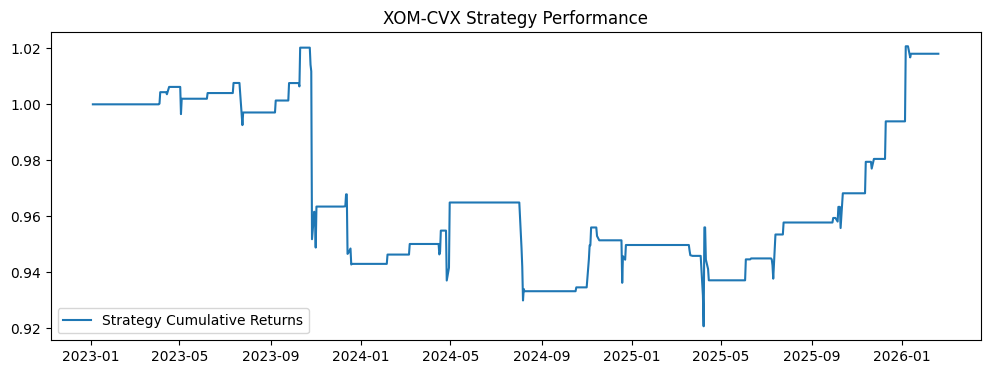

In [9]:
plt.figure(figsize=(12,4))
plt.plot(cum_ret, label='Strategy Cumulative Returns')
plt.title('XOM-CVX Strategy Performance')
plt.legend()
plt.show()